In [130]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler

# 0. Import Datasets:

In [131]:
customers_db = pd.read_csv("datasets/customer_db_with_outliers.csv", sep=",", index_col=0)
flights_db = pd.read_csv("datasets/flights_db_with_outliers.csv", sep=",", index_col=0)

# 1. Merge Customer and Flight Data

In [132]:
customers_db['Loyalty#'] = customers_db['Loyalty#'].astype(int)
flights_db['Loyalty#'] = flights_db['Loyalty#'].astype(int)

customer_flights_combined = pd.merge(customers_db, flights_db, on='Loyalty#', how='left')

In [133]:
customer_flights_combined["YearMonth"] = (
    customer_flights_combined["Year"].astype(str)
    + "-"
    + customer_flights_combined["Month"].astype(str).str.zfill(2)
)

customer_agg = (
    customer_flights_combined
    .groupby("Loyalty#", as_index=False)
    .agg(
        customer_name=("Customer Name", "first"),
        province=("Province or State", "first"),
        city=("City", "first"),
        latitude=("Latitude", "first"),
        longitude=("Longitude", "first"),
        postal_code=("Postal code", "first"),
        gender=("Gender", "first"),
        education=("Education", "first"),
        location_code=("Location Code", "first"),
        income=("Income", "first"),
        marital_status=("Marital Status", "first"),
        loyalty_status=("LoyaltyStatus", "first"),
        enrollment_date=("EnrollmentDateOpening", "first"),
        enrollment_type=("EnrollmentType", "first"),
        customer_lifetime_value=("Customer Lifetime Value", "first"),
        is_cancelled=("IsCancelled", "max"),
        tenure_months=("Tenure_months", "max"),
        NumFlights=("NumFlights", "sum"),
        NumFlightsWithCompanions=("NumFlightsWithCompanions", "sum"),
        DistanceKM=("DistanceKM", "sum"),
        PointsAccumulated=("PointsAccumulated", "sum"),
        PointsRedeemed=("PointsRedeemed", "sum"),
        DollarCostPointsRedeemed=("DollarCostPointsRedeemed", "sum"),
    )
)

flight_taken_ym = (
    customer_flights_combined
    .groupby(["Loyalty#", "YearMonth"])
    .size()
    .gt(0)
    .astype(int)
    .unstack(fill_value=0)
    .add_prefix("flight_taken_")
    .reset_index()
)

flights_count_ym = (
    customer_flights_combined
    .groupby(["Loyalty#", "YearMonth"])["NumFlights"]
    .sum()
    .unstack(fill_value=0)
    .add_prefix("flights_taken_")
    .reset_index()
)

usage_window = (
    customer_flights_combined
    .groupby("Loyalty#", as_index=False)
    .agg(
        first_active_month=("YearMonth", "min"),
        last_active_month=("YearMonth", "max"),
        total_active_months=("YearMonth", "nunique"),
        first_active_year=("Year", "min"),
        last_active_year=("Year", "max"),
    )
)

usage_window["first_active_month"] = pd.to_datetime(usage_window["first_active_month"])
usage_window["last_active_month"] = pd.to_datetime(usage_window["last_active_month"])

usage_window["activity_span_months"] = (
    (usage_window["last_active_month"].dt.year - usage_window["first_active_month"].dt.year) * 12
    + (usage_window["last_active_month"].dt.month - usage_window["first_active_month"].dt.month)
)

reference_month = pd.to_datetime(customer_flights_combined["YearMonth"].max())

usage_window["months_since_last_activity"] = (
    (reference_month.year - usage_window["last_active_month"].dt.year) * 12
    + (reference_month.month - usage_window["last_active_month"].dt.month)
)

final_customer_table = (
    customer_agg
    .merge(usage_window, on="Loyalty#", how="left")
    .merge(flight_taken_ym, on="Loyalty#", how="left")
    .merge(flights_count_ym, on="Loyalty#", how="left")
)

final_customer_table["avg_distance_per_flight"] = np.where(
    final_customer_table["NumFlights"] > 0,
    final_customer_table["DistanceKM"] / final_customer_table["NumFlights"],
    0
)

final_customer_table["companion_share"] = np.where(
    final_customer_table["NumFlights"] > 0,
    final_customer_table["NumFlightsWithCompanions"] / final_customer_table["NumFlights"],
    0
)


# final_customer_table.replace([np.inf, -np.inf], 0, inplace=True)
# final_customer_table.fillna(0, inplace=True)


customer_flights_combined = final_customer_table


## 1.1 Data Consistency and empty rows check

In [134]:
customer_flights_combined.columns.values

array(['Loyalty#', 'customer_name', 'province', 'city', 'latitude',
       'longitude', 'postal_code', 'gender', 'education', 'location_code',
       'income', 'marital_status', 'loyalty_status', 'enrollment_date',
       'enrollment_type', 'customer_lifetime_value', 'is_cancelled',
       'tenure_months', 'NumFlights', 'NumFlightsWithCompanions',
       'DistanceKM', 'PointsAccumulated', 'PointsRedeemed',
       'DollarCostPointsRedeemed', 'first_active_month',
       'last_active_month', 'total_active_months', 'first_active_year',
       'last_active_year', 'activity_span_months',
       'months_since_last_activity', 'flight_taken_2019-01',
       'flight_taken_2019-02', 'flight_taken_2019-03',
       'flight_taken_2019-04', 'flight_taken_2019-05',
       'flight_taken_2019-06', 'flight_taken_2019-07',
       'flight_taken_2019-08', 'flight_taken_2019-09',
       'flight_taken_2019-10', 'flight_taken_2019-11',
       'flight_taken_2019-12', 'flight_taken_2020-01',
       'flight_take

In [135]:
customer_flights_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16375 entries, 0 to 16374
Columns: 105 entries, Loyalty# to companion_share
dtypes: datetime64[ns](2), float64(11), int32(2), int64(79), object(11)
memory usage: 13.0+ MB


In [136]:
customer_flights_combined.isna().sum().sort_values(ascending=False)


Loyalty#                   0
customer_name              0
province                   0
city                       0
latitude                   0
                          ..
flights_taken_2021-10      0
flights_taken_2021-11      0
flights_taken_2021-12      0
avg_distance_per_flight    0
companion_share            0
Length: 105, dtype: int64

# 2 Feature Engineering

### 2.1.1 Customer Level Data Aggregation

In [137]:
# customer_level_dataset = customer_flights_combined.groupby('Loyalty#').agg({
#     'NumFlights': 'sum',
#     'NumFlightsWithCompanions': 'sum',
#     'DistanceKM': 'sum',
#     'PointsAccumulated': 'sum',
#     'PointsRedeemed': 'sum',
#     'DollarCostPointsRedeemed': 'sum',
#     'Tenure_months': 'max',
#     'Customer Lifetime Value': 'max',
#     'Income': 'mean',
#     'IsCancelled': 'max'
# }).reset_index()



### 2.1.2 Time based Data Aggregation 

In [138]:
# temporal_features = customer_flights_combined.groupby('Loyalty#').agg(
#     first_year=('Year', 'min'),
#     last_year=('Year', 'max'),
#     active_years=('Year', 'nunique'),
#     active_months=('YearMonthDate', 'nunique')
# ).reset_index()

### 2.1.3 Sesaon Based Data mapping and Aggregation

In [139]:
# season_map = {
#     12: 'winter', 1: 'winter', 2: 'winter',
#     3: 'spring', 4: 'spring', 5: 'spring',
#     6: 'summer', 7: 'summer', 8: 'summer',
#     9: 'fall', 10: 'fall', 11: 'fall'
# }

# customer_flights_combined['season'] = (
#     customer_flights_combined['Month'].map(season_map)
# )

# seasonal = (
#     customer_flights_combined
#     .groupby(['Loyalty#', 'season'])
#     .agg(total_flights=('NumFlights', 'sum'))
#     .reset_index()
# )

### 2.1.4 Activity Based Data Aggregation

In [140]:
# latest_year = customer_flights_combined['Year'].max()

# recent_activity = (
#     customer_flights_combined
#     .assign(is_recent=lambda x: x['Year'] >= latest_year - 1)
#     .groupby('Loyalty#')
#     .agg(recent_flights=('NumFlights', 'sum'))
#     .reset_index()
# )

### 2.1.5 Geo-Location Based Data Aggregation

In [141]:
# from sklearn.cluster import DBSCAN
# from sklearn.preprocessing import StandardScaler

# geo_data = (
#     customer_flights_combined
#     .groupby('Loyalty#')
#     .agg(
#         mean_lat=('Latitude', 'mean'),
#         mean_lon=('Longitude', 'mean')
#     )
#     .reset_index()
# )



## 2.1 Feature Engineering

In [142]:
fe_df = customer_flights_combined.copy()

## 2.2.1 Temporal Feature Engineering

Temporal feature engineering focuses on extracting meaningful patterns from time-based variables such as year and month. These features help capture seasonality, temporal trends, and behavioral differences in customer travel patterns. Incorporating temporal context is particularly important for clustering and segmentation, as customers may exhibit similar travel volumes but differ significantly in *when* they travel.

---

### 1. YearMonth

**Description**  
YearMonth is a composite temporal feature that combines the year and month into a single identifier. It represents customer activity at a monthly level while preserving the chronological order of events.

**Why this feature is created**  
Using year and month separately can fragment temporal analysis and make aggregation more complex. Combining them ensures that monthly granularity is preserved and prevents loss of temporal structure in the data.

**How it will be used**  
This feature will be used primarily for grouping and aggregation purposes, such as analyzing customer activity per month or identifying monthly travel trends. It is not intended to be used directly as an input feature for clustering, but rather as a structural element to support temporal analysis and feature aggregation.

---

### 2. is_peak_season_proxy

**Description**  
is_weekend_travel_proxy is a binary feature that indicates whether a customer’s travel occurred during peak vacation months (June, July, and August). A value of 1 represents travel during these peak months, while 0 represents travel outside this period.

**Why this feature is created**  
Exact information about weekends, holidays, or trip purpose is not available in the dataset. Summer months are strongly associated with leisure, family, and holiday travel. This feature serves as a proxy to capture those behavioral patterns.

**How it will be used**  
This feature helps distinguish leisure-oriented travelers from business or routine travelers. It introduces behavioral context into the clustering process and supports the identification of customer segments such as seasonal vacation travelers versus consistent year-round travelers.

---

### 3. season

**Description**  
The season feature categorizes each month into one of four seasons: winter, spring, summer, or fall. This provides a higher-level representation of temporal patterns compared to raw month values.

**Why this feature is created**  
Using individual months can introduce unnecessary noise and high cardinality. Mapping months to seasons captures broader seasonal travel behavior and smooths month-to-month variability while retaining meaningful temporal patterns.

**How it will be used**  
This feature will be used to analyze and compare customer behavior across different seasons. After appropriate encoding, it can be included in clustering models to help identify seasonal travel preferences and to improve interpretability of the resulting customer segments.

---

### Summary

The temporal features introduced in this section enhance the dataset by incorporating time-based behavioral context. Together, they enable better aggregation, improve interpretability of customer behavior, and support more meaningful clustering outcomes by accounting for *when* customers travel, not just *how much* they travel.


In [143]:
summer_cols = [
    c for c in fe_df.columns
    if c.startswith("flight_taken_")
    and c.endswith(("-06", "-07", "-08"))
]

fe_df["is_peak_season_proxy"] = (fe_df[summer_cols].sum(axis=1) > 0).astype(int)


In [144]:
season_months = {
    "winter": ("-12", "-01", "-02"),
    "spring": ("-03", "-04", "-05"),
    "summer": ("-06", "-07", "-08"),
    "fall":   ("-09", "-10", "-11"),
}

for season, suffixes in season_months.items():
    cols = [
        c for c in fe_df.columns
        if c.startswith("flights_taken_") and c.endswith(suffixes)
    ]
    fe_df[f"{season}_flight_count"] = fe_df[cols].sum(axis=1)

fe_df["season"] = (
    fe_df[["winter_flight_count", "spring_flight_count",
           "summer_flight_count", "fall_flight_count"]]
    .idxmax(axis=1)
    .str.replace("_flight_count", "")
)


## 2.2.2 Behavioral Feature Engineering

Behavioral feature engineering focuses on capturing how customers interact with the airline over time. Unlike raw counts, these features normalize customer activity and reflect intensity, engagement, and loyalty-related behavior. Such features are critical for clustering, as they help distinguish customers with similar volumes but different usage patterns.

---

### 1. flights_per_month

**Description**  
flights_per_month measures the average number of flights taken by a customer per month over their tenure. It represents the intensity and regularity of a customer’s travel behavior.

**Why this feature is created**  
Total flight counts alone do not account for how long a customer has been active. Normalizing flights by tenure allows fair comparison between new and long-term customers and avoids bias toward customers with longer histories.

**How it will be used**  
This feature will be used directly in clustering models to distinguish frequent travelers from occasional travelers. It helps identify high-engagement customers and separates consistent travelers from sporadic ones.

---

### 2. points_per_flight

**Description**  
points_per_flight represents the average number of loyalty points accumulated per flight by a customer.

**Why this feature is created**  
Raw point totals are heavily influenced by the number of flights taken. Normalizing points by flights provides insight into travel value per trip, capturing differences in ticket class, distance, or fare type.

**How it will be used**  
This feature will help differentiate customers who earn more value per flight, such as long-haul or premium travelers, from those who primarily take shorter or lower-value trips. It contributes to identifying high-value customer segments.

---

### 3. redeem_ratio

**Description**  
redeem_ratio measures the proportion of accumulated loyalty points that a customer has redeemed. It reflects how actively a customer uses their earned rewards.

**Why this feature is created**  
Accumulating points and redeeming points represent different aspects of customer behavior. This feature captures engagement with the loyalty program rather than just earning activity.

**How it will be used**  
This feature will help distinguish customers who actively redeem rewards from those who primarily accumulate points. It supports behavioral segmentation, such as identifying reward-driven customers versus long-term point accumulators.

---

### Summary

The behavioral features introduced in this section normalize customer activity and capture engagement intensity, value per interaction, and loyalty behavior. Together, they provide a richer representation of customer behavior and significantly improve the quality and interpretability of clustering results.


In [145]:
fe_df['flights_per_month'] = fe_df['NumFlights'] / fe_df['activity_span_months'].replace(0, 1)

fe_df['points_per_flight'] = fe_df['PointsAccumulated'] / fe_df['NumFlights'].replace(0, 1)

fe_df['redeem_ratio'] = fe_df['PointsRedeemed'] / fe_df['PointsAccumulated'].replace(0, 1)


## 2.2.3 Geographic Feature Engineering

Geographic feature engineering focuses on incorporating spatial information into the dataset to capture location-based travel patterns. Geographic features are especially important when the final objective includes geo-based clustering, as they allow the model to identify spatial similarities and regional travel behaviors among customers.

---

### 1. geo_point

**Description**  
geo_point is a composite geographic feature that represents a customer’s location as a pair of latitude and longitude coordinates. Together, these coordinates define a precise point on the Earth’s surface.

**Why this feature is created**  
Latitude and longitude stored separately are not directly suitable for spatial analysis or distance-based clustering. Combining them into a single geographic point preserves spatial relationships and enables the use of geographic distance metrics.

**How it will be used**  
This feature will be used as the foundation for geographic clustering and spatial analysis. It enables the identification of region-based customer segments, supports distance-based clustering methods, and allows analysis of geographic travel concentration. It is particularly useful for detecting clusters of customers with similar geographic origins or travel patterns.

---

### Summary

The geographic feature introduced in this section provides spatial context that complements temporal and behavioral features. By incorporating location information, the clustering process can capture regional similarities and produce more meaningful, geographically informed customer segments.


In [146]:
fe_df['latitude']

0        53.544388
1        43.653225
2        55.759628
3        49.282730
4        43.653225
           ...    
16370    43.653225
16371    47.561508
16372    46.813877
16373    48.428421
16374    45.421532
Name: latitude, Length: 16375, dtype: float64

In [147]:
fe_df['geo_point'] = list(zip(fe_df['latitude'], fe_df['longitude']))


In [148]:
fe_df.drop(columns=['latitude', 'longitude'], inplace=True)


In [149]:
fe_df.isna().sum().sort_values(ascending=True)

Loyalty#             0
customer_name        0
province             0
city                 0
postal_code          0
                    ..
season               0
flights_per_month    0
points_per_flight    0
redeem_ratio         0
geo_point            0
Length: 113, dtype: int64

In [150]:
fe_df

,Loyalty#,customer_name,province,city,postal_code,gender,education,location_code,income,marital_status,...,is_peak_season_proxy,winter_flight_count,spring_flight_count,summer_flight_count,fall_flight_count,season,flights_per_month,points_per_flight,redeem_ratio,geo_point
0,100018,Mina Smida,Alberta,Edmonton,T9G 1W3,female,Bachelor,Rural,82877.0,Married,...,1,45,47,55,84,fall,6.600000,229.499134,0.387873,"(53.544388, -113.49093)"
1,100102,Rigoberto Palacio,Ontario,Toronto,M1R 4K3,male,College,Urban,0.0,Single,...,1,60,62,49,77,fall,7.085714,136.709516,0.553345,"(43.653225, -79.383186)"
2,100140,Nakesha Klaass,British Columbia,Dawson Creek,V5R 1W3,female,College,Suburban,0.0,Divorced,...,1,49,58,48,62,fall,6.200000,199.044147,0.113353,"(55.759628, -120.23766)"
3,100214,Loren Juenemann,British Columbia,Vancouver,V5R 1W3,male,Bachelor,Suburban,42837.0,Married,...,1,43,3,18,48,fall,3.200000,325.480089,0.354109,"(49.28273, -123.12074)"
4,100272,Siobhan Lander,Ontario,Toronto,P1L 8X8,female,Bachelor,Suburban,80979.0,Divorced,...,1,31,64,70,22,summer,5.342857,229.696524,0.253564,"(43.653225, -79.383186)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16370,999902,Rhoda Brugliera,Ontario,Toronto,M1R 4K3,male,College,Urban,0.0,Married,...,1,53,55,112,47,summer,7.628571,228.488951,0.172142,"(43.653225, -79.383186)"
16371,999911,Corrinne Lewison,Newfoundland,St. John's,A1C 6H9,male,Doctor,Suburban,23506.0,Single,...,1,0,0,0,0,winter,0.000000,0.000000,0.000000,"(47.561508, -52.712578)"
16372,999940,Pura Dejulio,Quebec,Quebec City,G1B 3L5,female,Bachelor,Suburban,21542.0,Married,...,1,33,2,13,37,fall,2.428571,270.630353,0.244310,"(46.813877, -71.207977)"
16373,999982,Gladis Sweeton,British Columbia,Victoria,V5R 1W3,male,College,Urban,0.0,Married,...,1,0,0,8,14,fall,0.647059,187.363636,0.000000,"(48.428421, -123.36565)"


In [151]:
fe_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16375 entries, 0 to 16374
Columns: 113 entries, Loyalty# to geo_point
dtypes: datetime64[ns](2), float64(12), int32(2), int64(84), object(13)
memory usage: 14.0+ MB


# 3 Discretization and Binning of Customer-Level Features

After performing customer-level aggregation, discretization (binning) was applied to several numerical features. Discretization transforms continuous variables into categorical ranges, improving interpretability, reducing the impact of skewed distributions, and making behavioral patterns more explicit for clustering and analysis.

---

### Customer-Level Representation

**Why one row per customer**  
The dataset was aggregated such that each row represents a single customer. This ensures that every customer contributes equally to the clustering process and avoids bias introduced by customers with a large number of flights. Customer-level representation allows direct comparison of overall behavior, value, and engagement across individuals.

---

### Distribution Analysis Using Histograms

**Why histograms were used**  
Histograms were plotted for all numerical customer-level features to examine their distributions, identify skewness, and detect the presence of outliers. Many variables exhibited strong right skewness, with a small number of customers having extremely high values.

**How this informed discretization**  
Due to skewed distributions, direct use of raw numerical values could dominate distance-based clustering. Discretization was therefore used to group values into meaningful ranges while preserving relative behavioral differences.

---

### Binned Feature Definitions and Thresholds

#### clv_band (Customer Lifetime Value)

Customers were divided into value-based segments using the following thresholds:
- **Low value**: up to 5,000  
- **Mid value**: 5,001 to 15,000  
- **High value**: 15,001 to 30,000  
- **Very high value**: above 30,000  

This division separates low-impact customers from high-value and premium customers while controlling for extreme CLV outliers.

---

#### points_redeemed_band

Redemption behavior was discretized as:
- **None**: no points redeemed  
- **Low**: up to 5,000 points  
- **Medium**: 5,001 to 15,000 points  
- **High**: above 15,000 points  

These thresholds reflect increasing engagement with the loyalty rewards system.

---

#### num_flights_band

Flight frequency was categorized as:
- **No travel**: 0 flights  
- **Occasional**: 1 to 3 flights  
- **Regular**: 4 to 8 flights  
- **Frequent**: more than 8 flights  

This binning distinguishes infrequent travelers from consistently active customers.

---

#### companion_flights_band

Companion travel behavior was divided into:
- **Solo only**: no companion flights  
- **Occasional companion**: 1 to 2 companion flights  
- **Family traveler**: 3 to 6 companion flights  
- **Group traveler**: more than 6 companion flights  

These thresholds capture differences between solo travelers and customers who frequently travel with others.

---

#### avg_distance_band

Average distance per flight was categorized as:
- **No flights**: no recorded flights  
- **Short-haul traveler**: up to 1,500 km  
- **Medium-haul traveler**: 1,501 to 3,500 km  
- **Long-haul traveler**: above 3,500 km  

This discretization separates regional travelers from long-distance flyers.

---

#### redeem_ratio_band

Reward usage intensity was divided using the following ratios:
- **No points**: no accumulated points  
- **Rare redeemer**: up to 10% redemption  
- **Light redeemer**: 10% to 40% redemption  
- **Active redeemer**: 40% to 80% redemption  
- **Heavy redeemer**: above 80% redemption  

This captures how actively customers convert earned points into rewards.

---

#### tenure_band

Customer tenure was grouped as:
- **New customer**: up to 12 months  
- **Established**: 13 to 36 months  
- **Loyal**: 37 to 72 months  
- **Veteran**: more than 72 months  

These thresholds represent different stages of the customer lifecycle.

---

#### income_band

Income levels were discretized as:
- **Low income**: up to 30,000  
- **Mid income**: 30,001 to 60,000  
- **Upper mid income**: 60,001 to 100,000  
- **High income**: above 100,000  

Income bands provide socio-economic context that supports interpretation of customer clusters.

---

### Summary

Discretization was applied after customer-level aggregation and distribution analysis to handle skewness, reduce sensitivity to outliers, and improve interpretability. The resulting binned features provide meaningful behavioral categories that enhance clustering stability and make resulting customer segments easier to understand and explain.


In [152]:
numeric_cols = [
    c for c in fe_df
        .select_dtypes(include=["int64", "float64"])
        .columns
    if c != "Loyalty#"
    and fe_df[c].nunique() > 2
    and not c.startswith("flights_taken_")
]



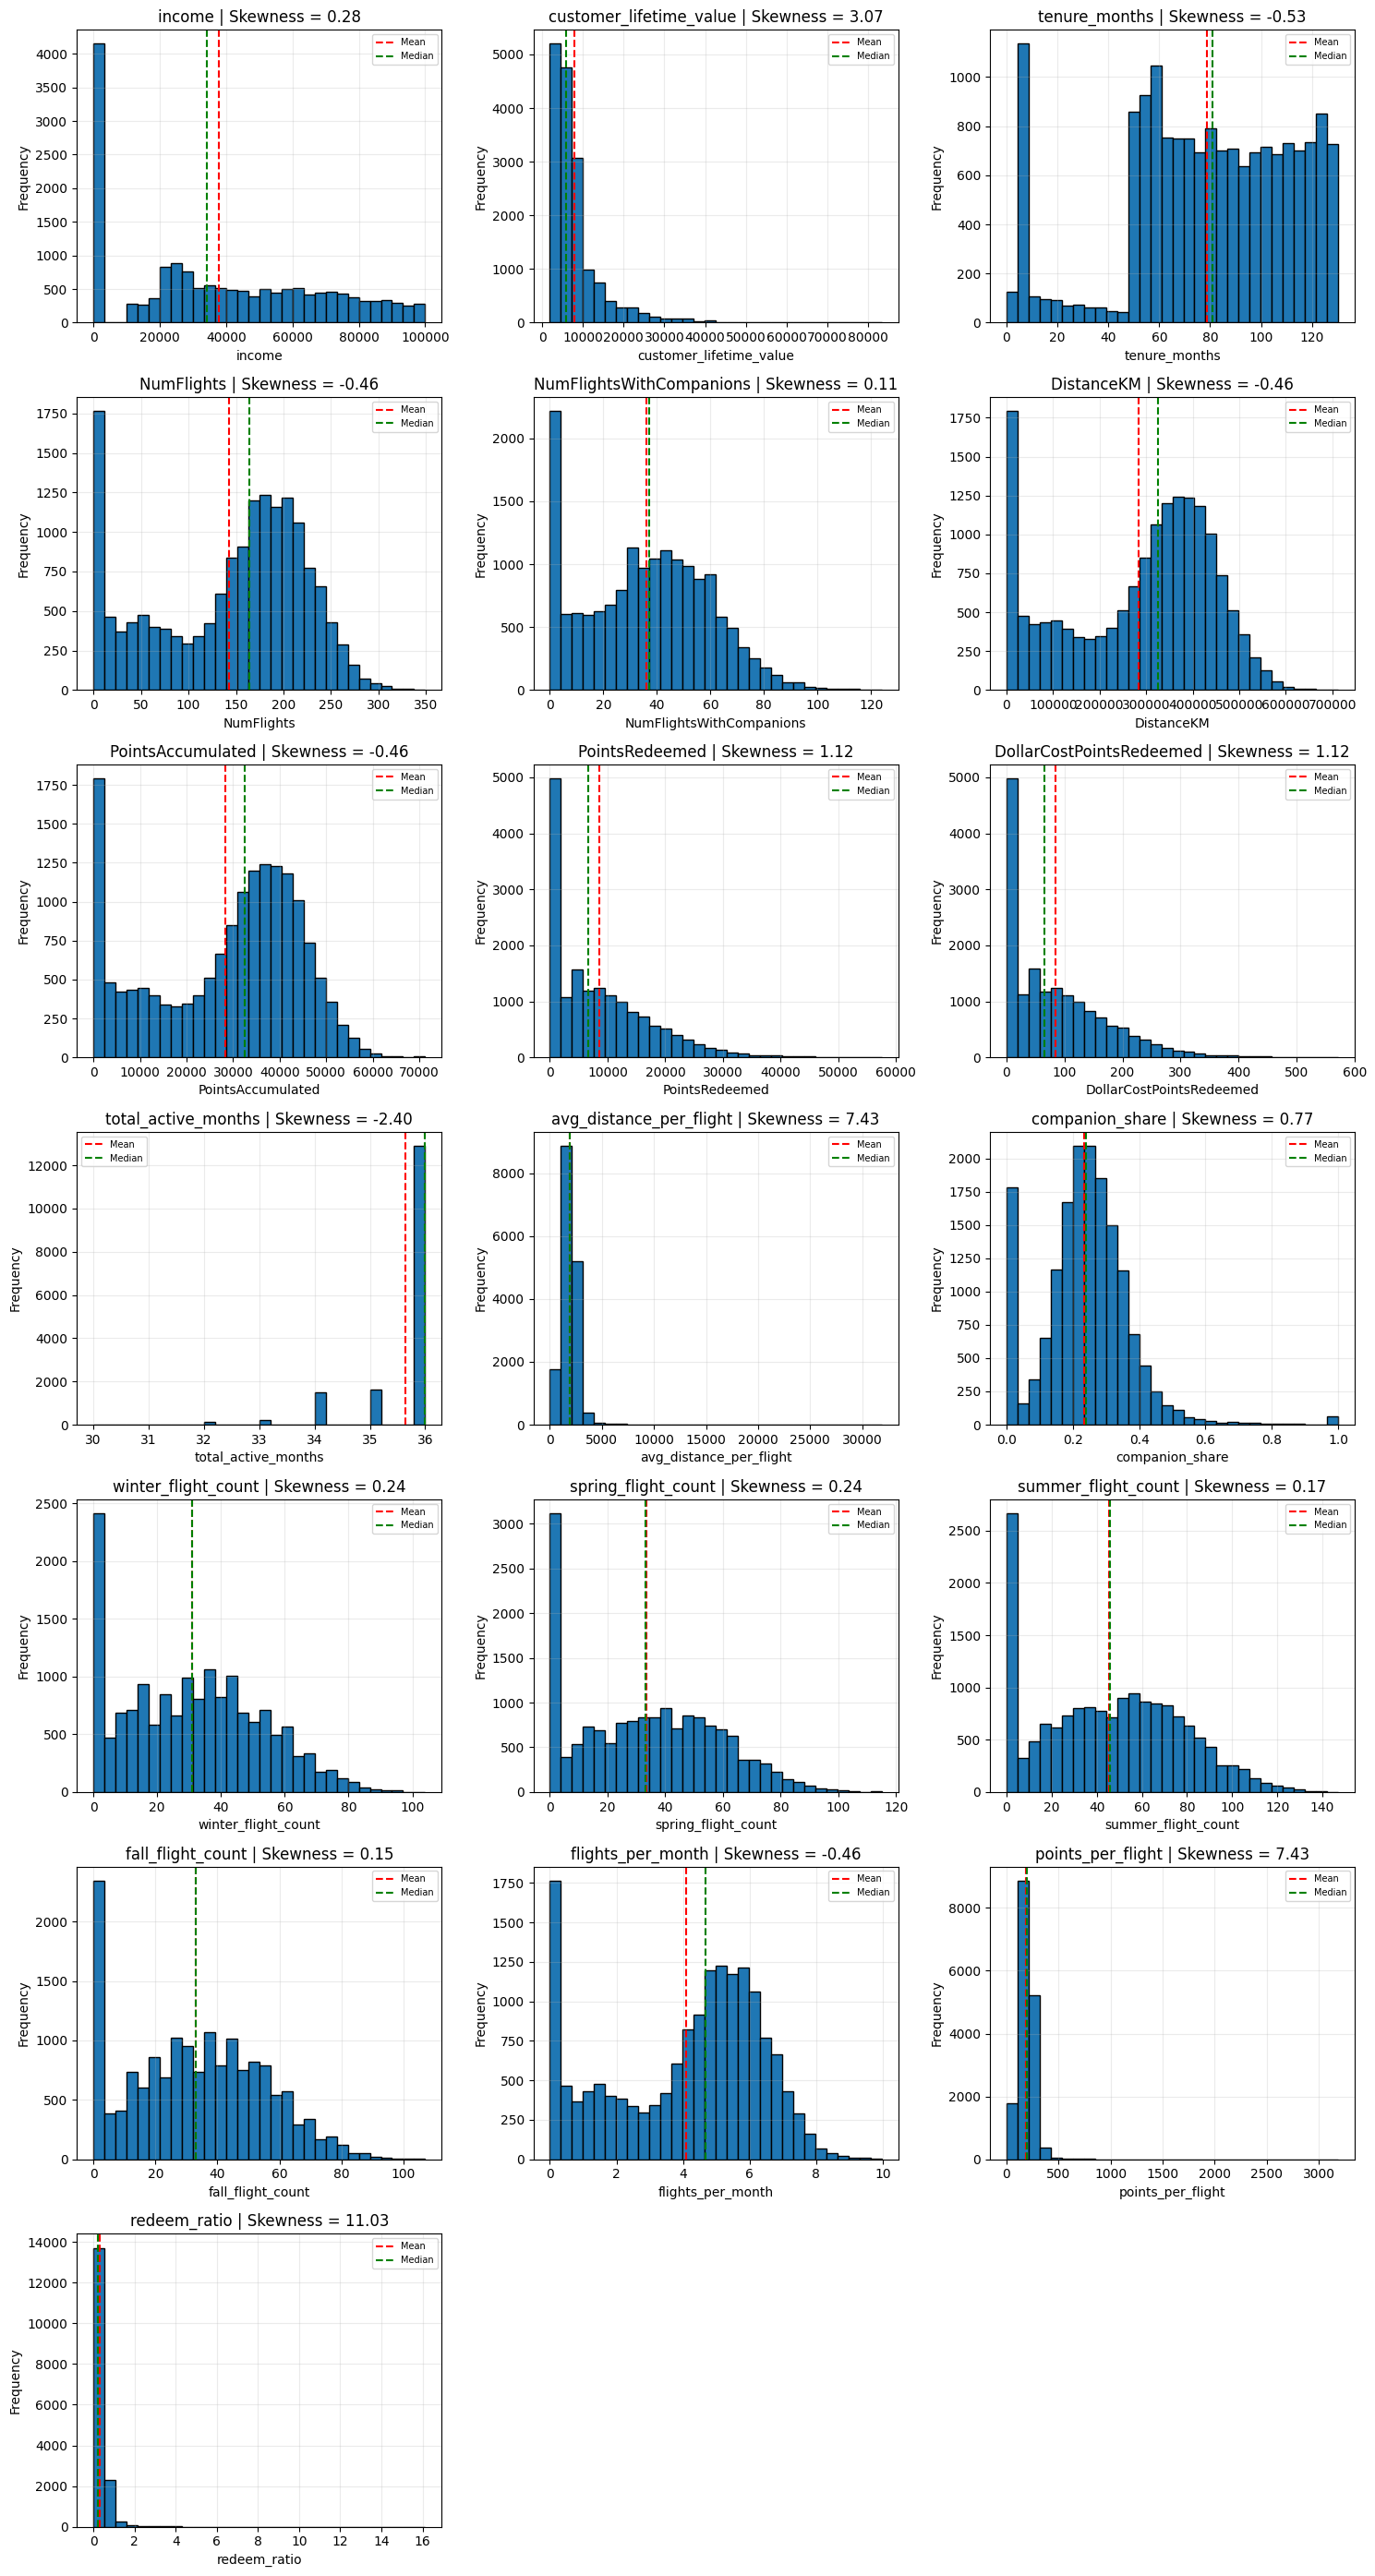

In [153]:
def plot_skewness_grid(df, cols, bins=30, figsize=(15, 4)):

    n = len(cols)
    if n == 0:
        return

    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize[0], figsize[1] * nrows)
    )
    axes = np.atleast_1d(axes).ravel()

    for i, c in enumerate(cols):
        ax = axes[i]
        s = df[c].dropna()
        if s.empty:
            ax.set_visible(False)
            continue

        skew = s.skew()

        ax.hist(s, bins=bins, edgecolor="black")
        ax.axvline(s.mean(), color="red", linestyle="--", label="Mean")
        ax.axvline(s.median(), color="green", linestyle="--", label="Median")

        ax.set_title(f"{c} | Skewness = {skew:.2f}")
        ax.set_xlabel(c)
        ax.set_ylabel("Frequency")
        ax.legend(fontsize=7)
        ax.grid(alpha=0.25)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()



plot_skewness_grid(fe_df, numeric_cols)

In [154]:
fe_df.describe()

,Loyalty#,income,customer_lifetime_value,is_cancelled,tenure_months,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,...,avg_distance_per_flight,companion_share,is_peak_season_proxy,winter_flight_count,spring_flight_count,summer_flight_count,fall_flight_count,flights_per_month,points_per_flight,redeem_ratio
count,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,...,16375.000000,16375.000000,16375.0,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000
mean,549432.932641,37721.547359,7982.088433,0.124947,78.890644,142.865527,36.013618,284344.443652,28428.845635,8601.144116,...,1901.642979,0.235229,1.0,30.935573,33.333802,45.616611,32.979542,4.084680,190.124675,0.291659
min,100018.000000,0.000000,1898.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,326276.000000,0.000000,3979.390000,0.000000,57.800000,75.000000,17.000000,150940.300000,15090.480000,0.000000,...,1602.668211,0.165854,1.0,13.000000,12.000000,19.000000,16.000000,2.142857,160.239253,0.000000
50%,550434.000000,34115.000000,5781.020000,0.000000,80.900000,164.000000,37.000000,326066.000000,32600.040000,6627.000000,...,1937.571101,0.238411,1.0,31.000000,33.000000,46.000000,33.000000,4.685714,193.726940,0.221774
75%,771330.000000,62375.000000,8936.970000,0.000000,106.300000,204.000000,53.000000,406698.450000,40662.755000,13663.850000,...,2280.893431,0.308669,1.0,47.000000,52.000000,69.000000,49.000000,5.828571,228.041211,0.428180
max,999986.000000,99981.000000,83325.380000,1.000000,130.300000,349.000000,124.000000,712729.600000,71264.460000,57527.800000,...,31875.000000,1.000000,1.0,104.000000,115.000000,147.000000,107.000000,9.971429,3187.000000,16.125899
std,258720.547621,30342.177810,6841.119253,0.330668,33.343340,80.021292,23.298295,159594.566701,15956.795148,8707.423785,...,1087.255919,0.133763,0.0,21.567236,24.583544,31.626458,21.913014,2.288036,108.708076,0.415980


In [155]:
fe_df['clv_band'] = pd.cut(
    fe_df['customer_lifetime_value'].fillna(0),
    bins=[-1, 5000, 15000, 30000, np.inf],
    labels=['low_value', 'mid_value', 'high_value', 'very_high_value']
)

fe_df['points_redeemed_band'] = pd.cut(
    fe_df['PointsRedeemed'].fillna(0),
    bins=[-1, 0, 1000, 5000, np.inf],
    labels=['none', 'low', 'medium', 'high']
)

fe_df['num_flights_band'] = pd.cut(
    fe_df['NumFlights'].fillna(0),
    bins=[-1, 0, 3, 8, np.inf],
    labels=['no_travel', 'occasional', 'regular', 'frequent']
)

fe_df['companion_flights_band'] = pd.cut(
    fe_df['NumFlightsWithCompanions'].fillna(0),
    bins=[-1, 0, 2, 6, np.inf],
    labels=['solo_only', 'occasional_companion', 'family_traveler', 'group_traveler']
)

fe_df['avg_distance_per_flight'] = np.where(
    fe_df['NumFlights'] > 0,
    fe_df['DistanceKM'] / fe_df['NumFlights'],
    0
)

fe_df['avg_distance_per_flight_band'] = pd.cut(
    fe_df['avg_distance_per_flight'],
    bins=[-1, 0, 1500, 3500, np.inf],
    labels=['no_flights', 'short_haul_traveler', 'medium_haul_traveler', 'long_haul_traveler']
)

fe_df['redeem_ratio'] = np.where(
    fe_df['PointsAccumulated'] > 0,
    fe_df['PointsRedeemed'] / fe_df['PointsAccumulated'],
    0
)

fe_df['redeem_ratio_band'] = pd.cut(
    fe_df['redeem_ratio'],
    bins=[-1, 0, 0.1, 0.4, 0.8, np.inf],
    labels=['no_points', 'rare_redeemer', 'light_redeemer', 'active_redeemer', 'heavy_redeemer']
)

fe_df['tenure_band'] = pd.cut(
    fe_df['tenure_months'].fillna(0),
    bins=[-1, 12, 36, 72, np.inf],
    labels=['new_customer', 'established', 'loyal', 'veteran']
)

fe_df['income_band'] = pd.cut(
    fe_df['income'].fillna(0),
    bins=[-1, 30000, 60000, 100000, np.inf],
    labels=['low_income', 'mid_income', 'upper_mid_income', 'high_income']
)
fe_df
fe_df.isna().sum().sort_values(ascending=True)

Loyalty#                        0
customer_name                   0
province                        0
city                            0
postal_code                     0
                               ..
companion_flights_band          0
avg_distance_per_flight_band    0
redeem_ratio_band               0
tenure_band                     0
income_band                     0
Length: 121, dtype: int64

In [156]:
fe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16375 entries, 0 to 16374
Columns: 121 entries, Loyalty# to income_band
dtypes: category(8), datetime64[ns](2), float64(12), int32(2), int64(84), object(13)
memory usage: 14.1+ MB


# OUTLIERS (IQR):

In [157]:
def boxplot_grid(df, cols, ncols=3, figsize=(14, 8), showfliers=True):
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(cols):
        ax = axes[i]
        s = df[col].astype(float)
        ax.boxplot(s.dropna().values, vert=True, showmeans=False, showfliers=showfliers)
        ax.set_title(f"Boxplot of {col}")
        ax.set_xticks([])                 
        ax.set_ylabel(col)
        ax.grid(axis="y", alpha=0.25)

    # Hide unused subplot:
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

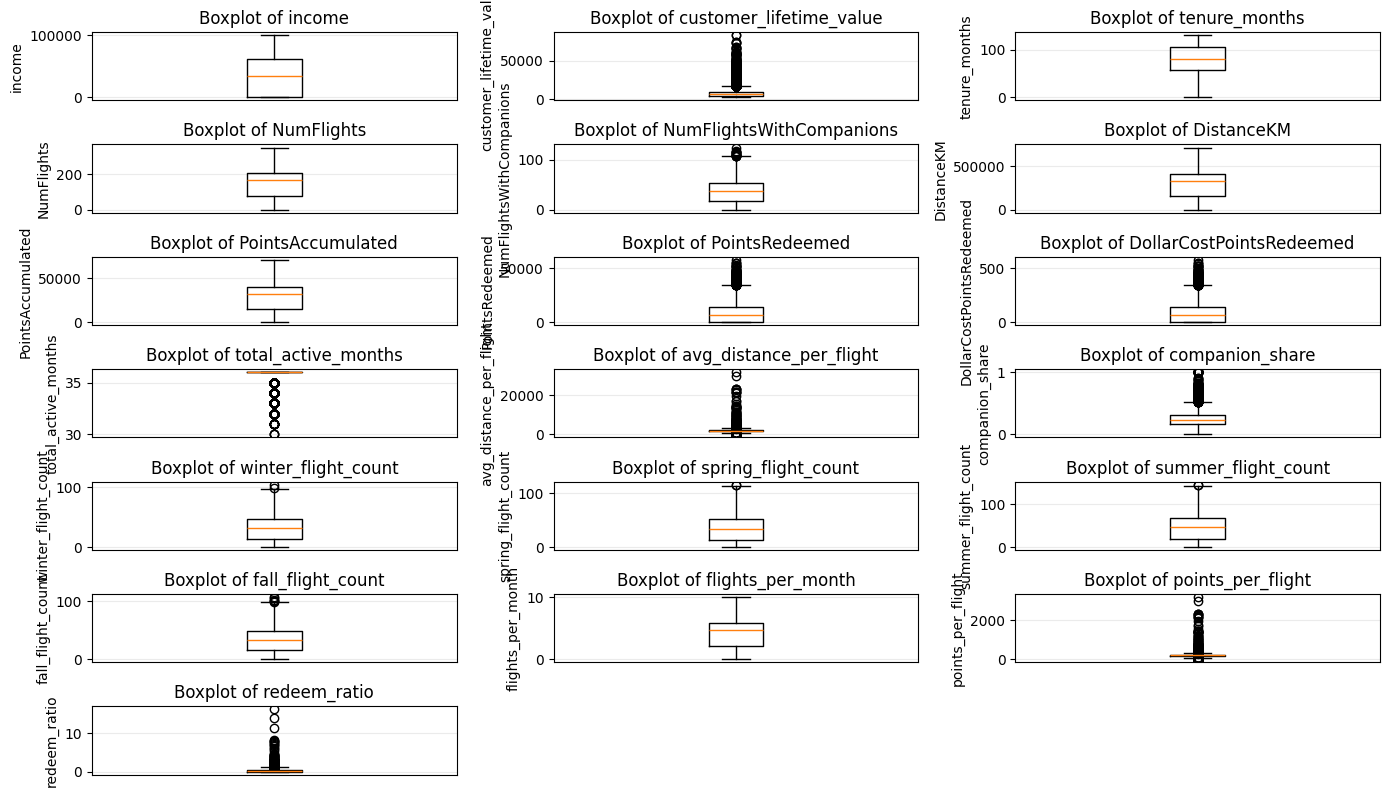

In [158]:
boxplot_grid(fe_df, numeric_cols, ncols=3, figsize=(14, 8), showfliers=True)

In [159]:
def iqr_outlier_summary(df: pd.DataFrame, cols, k: float = 1.5):

    rows = []
    masks = {}

    n = len(df)

    for col in cols:
        s = df[col].dropna()

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        lower = q1 - k * iqr
        upper = q3 + k * iqr

        mask = (df[col] < lower) | (df[col] > upper)
        n_out = mask.sum()
        pct_out = n_out / n * 100

        masks[col] = mask

        rows.append({
            "feature": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "n_outliers": n_out,
            "pct_outliers": pct_out
        })

    summary_df = pd.DataFrame(rows)

    print("-" * 70)
    print("IQR outlier summary")
    print("-" * 70)
    for _, r in summary_df.iterrows():
        print(f"Feature        : {r['feature']}")
        print(f"  Q1           : {r['Q1']:.3f}")
        print(f"  Q3           : {r['Q3']:.3f}")
        print(f"  IQR          : {r['IQR']:.3f}")
        print(f"  Lower bound  : {r['lower_bound']:.3f}")
        print(f"  Upper bound  : {r['upper_bound']:.3f}")
        print(f"  Outliers     : {int(r['n_outliers'])} "
              f"({r['pct_outliers']:.2f}% of rows)")
        print("-" * 70)

    return summary_df, masks


In [160]:
iqr_summary, iqr_masks = iqr_outlier_summary(fe_df, numeric_cols)

----------------------------------------------------------------------
IQR outlier summary
----------------------------------------------------------------------
Feature        : income
  Q1           : 0.000
  Q3           : 62375.000
  IQR          : 62375.000
  Lower bound  : -93562.500
  Upper bound  : 155937.500
  Outliers     : 0 (0.00% of rows)
----------------------------------------------------------------------
Feature        : customer_lifetime_value
  Q1           : 3979.390
  Q3           : 8936.970
  IQR          : 4957.580
  Lower bound  : -3456.980
  Upper bound  : 16373.340
  Outliers     : 1447 (8.84% of rows)
----------------------------------------------------------------------
Feature        : tenure_months
  Q1           : 57.800
  Q3           : 106.300
  IQR          : 48.500
  Lower bound  : -14.950
  Upper bound  : 179.050
  Outliers     : 0 (0.00% of rows)
----------------------------------------------------------------------
Feature        : NumFlights
  Q1 

In [161]:
manual_cols = [
    "total_active_months",
    "points_per_flight",
    "avg_distance_per_flight",
    "customer_lifetime_value",
]

qs = [0.99, 0.995, 0.999]  

rows = []
n = len(fe_df)

for col in manual_cols:
    s = fe_df[col].dropna()

    for q in qs:
        thr = float(s.quantile(q))
        removed_pct = 100 * (fe_df[col] > thr).mean()  
        rows.append({
            "feature": col,
            "quantile": q,
            "suggested_thr": thr,
            "pct_above_thr": removed_pct
        })

suggest_df = pd.DataFrame(rows).sort_values(["feature", "quantile"])
display(suggest_df)


,feature,quantile,suggested_thr,pct_above_thr
6,avg_distance_per_flight,0.990,4139.480733,1.001527
7,avg_distance_per_flight,0.995,5435.803333,0.500763
8,avg_distance_per_flight,0.999,14138.018700,0.103817
9,customer_lifetime_value,0.990,35872.633400,1.001527
10,customer_lifetime_value,0.995,41787.900000,0.458015
11,customer_lifetime_value,0.999,59882.126060,0.103817
3,points_per_flight,0.990,413.887545,1.001527
4,points_per_flight,0.995,543.558667,0.500763
5,points_per_flight,0.999,1413.639670,0.103817
0,total_active_months,0.990,36.000000,0.000000


In [166]:
q = 0.999
manual_quantile_cols = [
    "points_per_flight",
    "avg_distance_per_flight",
    "customer_lifetime_value",
]

manual_thresholds = {
    col: float(fe_df[col].dropna().quantile(q))
    for col in manual_quantile_cols
}

base_index = customers_db.index

per_feature_flags = {}
rows = []

for col, iqr_mask in iqr_masks.items():
    iqr_mask = iqr_mask.reindex(base_index, fill_value=False)

    if col in fe_df.columns:
        x = fe_df[col].reindex(base_index)
    else:
        x = None

    if col in manual_thresholds:
        thr = manual_thresholds[col]
        manual_mask = (x > thr)
        flag = iqr_mask & manual_mask
        rule = f"IQR & manual(q={q})"

    elif col == "total_active_months":
        tam = fe_df["total_active_months"].reindex(base_index)
        ten = fe_df["tenure_months"].reindex(base_index)
        manual_mask = (tam > ten)
        flag = iqr_mask & manual_mask
        rule = "IQR & manual(tam > tenure)"

    else:
        flag = iqr_mask
        rule = "IQR"

    per_feature_flags[col] = flag

    n = int(flag.sum())
    pct = 100 * n / len(base_index)

    rows.append({
        "feature": col,
        "rule": rule,
        "n_removed_by_feature": n,
        "pct_removed_by_feature": pct
    })

summary_df = pd.DataFrame(rows).sort_values("pct_removed_by_feature", ascending=False)

out_remove_total = pd.Series(False, index=base_index)
for flag in per_feature_flags.values():
    out_remove_total |= flag

total_n = int(out_remove_total.sum())
total_pct = 100 * total_n / len(base_index)

print(f"TOTAL to remove: {total_n} / {len(base_index)}  ({total_pct:.2f}%)")
print("\nTop features by % removed:")
display(summary_df.head(20))

print("\nManual thresholds (q=0.999):")
for k, v in manual_thresholds.items():
    print(f"  {k}: {v}")

TOTAL to remove: 880 / 16375  (5.37%)

Top features by % removed:


,feature,rule,n_removed_by_feature,pct_removed_by_feature
18,redeem_ratio,IQR,383,2.338931
11,companion_share,IQR,295,1.801527
8,DollarCostPointsRedeemed,IQR,182,1.111450
7,PointsRedeemed,IQR,178,1.087023
9,total_active_months,IQR & manual(tam > tenure),91,0.555725
1,customer_lifetime_value,IQR & manual(q=0.999),17,0.103817
17,points_per_flight,IQR & manual(q=0.999),17,0.103817
10,avg_distance_per_flight,IQR & manual(q=0.999),17,0.103817
4,NumFlightsWithCompanions,IQR,16,0.097710
15,fall_flight_count,IQR,6,0.036641



Manual thresholds (q=0.999):
  points_per_flight: 1413.639670000036
  avg_distance_per_flight: 14138.018700000353
  customer_lifetime_value: 59882.12606000365


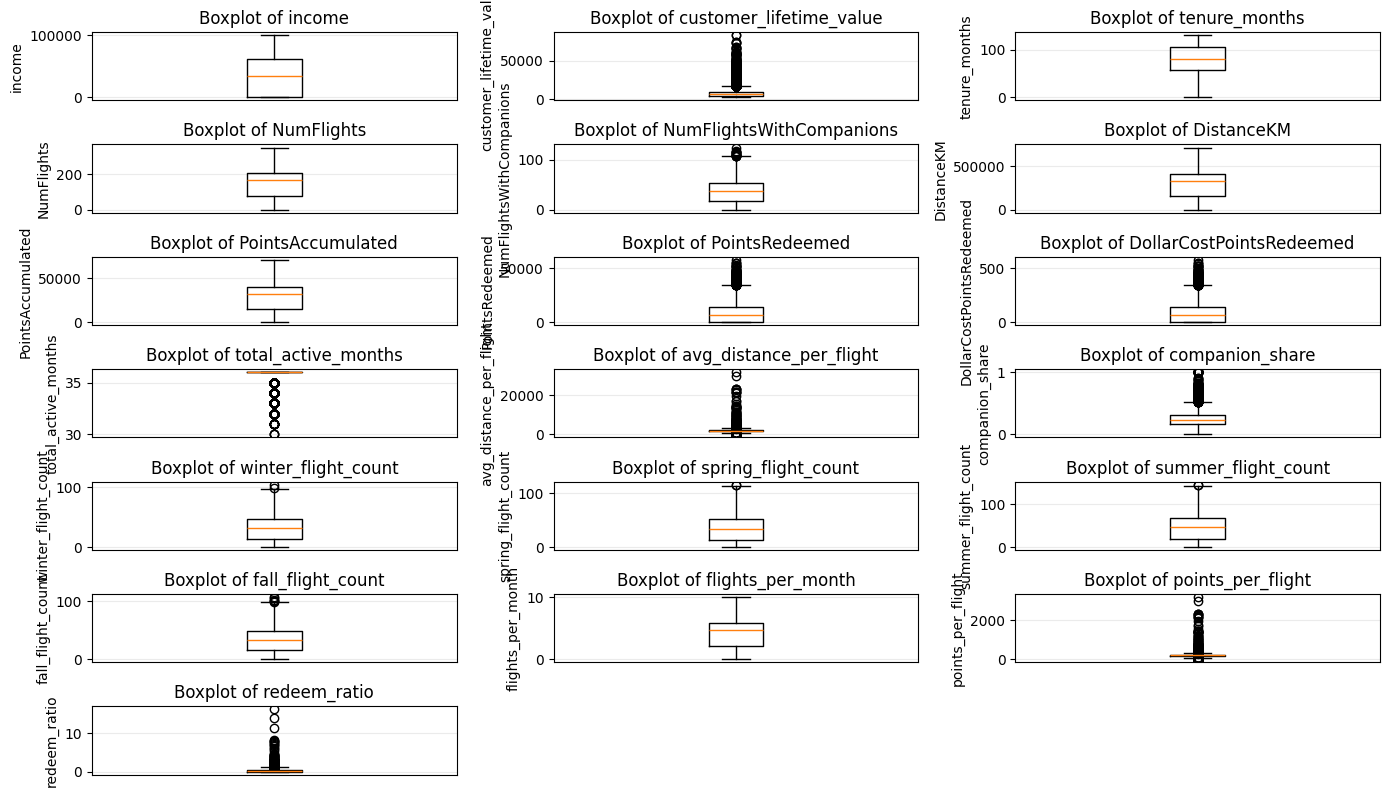

In [167]:
boxplot_grid(fe_df, numeric_cols, ncols=3, figsize=(14, 8), showfliers=True)

We identified potential outliers using a two-step strategy combining an univariate IQR rule and targeted manual filters. First, for each numeric feature we computed IQR-based bounds (Q1 − 1.5·IQR, Q3 + 1.5·IQR) and flagged observations falling outside these limits. For a small set of highly skewed, business-critical variables (e.g., points_per_flight, avg_distance_per_flight, and customer_lifetime_value), we additionally applied manual upper thresholds defined at the 99.9th percentile, and removed records only when both the IQR criterion and the corresponding manual threshold were triggered. Finally, we enforced a consistency rule by flagging and removing cases where total_active_months exceeded tenure_months, since active months cannot logically surpass the total observed membership duration.

In total we removed ~5% of the total data.

## 4. Feature Encoding

After completing feature engineering and discretization, encoding strategies were applied to transform categorical variables into numerical representations suitable for clustering algorithms. Encoding decisions were made carefully to preserve interpretability, maintain flexibility for future analysis, and ensure meaningful distance calculations.

---

### Dataset Structure at This Stage

Two datasets are used at this point in the pipeline:

- **fe_df**: A large, enriched flight-level dataset containing demographic, temporal, behavioral, and geographic attributes.
- **customer_level_df**: A customer-level dataset where each row represents a single customer, including aggregated numerical features and discretized (binned) behavioral features.

Encoding strategies differ between these datasets based on their purpose and intended use.

---

### Encoding Strategy for `fe_df` (Flight-Level Dataset)

The `fe_df` dataset is primarily used for exploratory analysis, feature derivation, and potential downstream modeling. Encoding was applied selectively.

#### Encoded Features in `fe_df`

Only the following nominal categorical features were encoded:
- Gender  
- Education  
- Location Code  
- Marital Status  
- Loyalty Status  
- Season  

These features do not have a natural order and represent independent categories.

#### Why Only These Features Were Encoded

- These variables are commonly used demographic or contextual attributes.
- Encoding allows them to participate in numerical analysis without introducing artificial ordering.
- Other categorical attributes were left untouched to preserve analytical flexibility.

#### Encoding Method Used

One-hot encoding was applied to these features.

- One-hot encoding avoids imposing ordinal relationships where none exist.
- All categories were retained to preserve interpretability.
- Multicollinearity was not a concern, as `fe_df` is not used directly as the final clustering input.


### Encoding Strategy for `customer_level_df` (Customer-Level Dataset)

The `customer_level_df` dataset serves as the primary input for clustering. Each row represents one customer, ensuring equal contribution to distance-based similarity calculations.

---

### Encoding of Discretized (Binned) Features

All discretized features created during the binning stage were encoded.

#### Why These Features Were Encoded

- Clustering algorithms require numerical input.
- Binned features already represent simplified and meaningful behavioral categories.
- Encoding allows these features to directly influence distance-based similarity measures.

---

### Choice of Ordinal Encoding

Ordinal encoding was applied to the binned categorical features.

#### Why Ordinal Encoding Was Used

- The binned features have a natural and meaningful order.
- Ordinal encoding preserves this ordering relationship.
- It allows the clustering algorithm to recognize relative magnitude rather than treating categories as unrelated.

Examples of preserved order include:
- Low value < Mid value < High value < Very high value  
- No travel < Occasional < Regular < Frequent  
- New customer < Established < Loyal < Veteran  

---

### Encoded Feature Groups in `customer_level_df`

The following binned features were encoded using ordinal encoding:
- Customer Lifetime Value bands  
- Points redeemed bands  
- Number of flights bands  
- Companion flights bands  
- Average distance bands  
- Redemption ratio bands  
- Tenure bands  
- Income bands  

Each feature was encoded using a predefined category order to ensure consistent and interpretable numerical mapping.

---

### Summary

Encoding strategies were tailored to the role of each dataset.  
In `fe_df`, selective one-hot encoding was applied to nominal demographic and seasonal attributes while preserving location-based features for future use.  
In `customer_level_df`, ordinal encoding was applied to discretized behavioral features to preserve meaningful order and support effective clustering.

This balanced approach ensures numerical compatibility with clustering algorithms while maintaining interpretability and analytical flexibility.


In [ ]:
fe_df_encoded = fe_df.copy()

fe_categorical_cols = [
    'gender',
    'education',
    'location_code',
    'marital_status',
    'loyalty_status',
    'season',
]

fe_df_encoded = pd.get_dummies(
    fe_df_encoded,
    columns=fe_categorical_cols,
    drop_first=False
)


In [ ]:
ordinal_columns = [
    'clv_band',
    'points_redeemed_band',
    'num_flights_band',
    'companion_flights_band',
    'avg_distance_per_flight_band',
    'redeem_ratio_band',
    'tenure_band',
    'income_band'
]

ordinal_categories = [
    ['low_value', 'mid_value', 'high_value', 'very_high_value'],
    ['none', 'low', 'medium', 'high'],
    ['no_travel', 'occasional', 'regular', 'frequent'],
    ['solo_only', 'occasional_companion', 'family_traveler', 'group_traveler'],
    ['no_flights', 'short_haul_traveler', 'medium_haul_traveler', 'long_haul_traveler'],
    ['no_points', 'rare_redeemer', 'light_redeemer', 'active_redeemer', 'heavy_redeemer'],
    ['new_customer', 'established', 'loyal', 'veteran'],
    ['low_income', 'mid_income', 'upper_mid_income', 'high_income']
]
fe_df_encoded = fe_df_encoded.copy()

ordinal_encoder = OrdinalEncoder(categories=ordinal_categories)

fe_df_encoded[ordinal_columns] = ordinal_encoder.fit_transform(
    fe_df_encoded[ordinal_columns]
)


In [ ]:
fe_df_encoded.info()

## 6. Log Transformation of Skewed Features

Before applying feature scaling, numerical variables were analyzed for skewness to identify distributions that could negatively impact clustering performance. This step focuses on correcting distributional imbalance caused by extreme values.

---

### Why Log Transformation Was Necessary

Several customer-level numerical features represent accumulated or monetary quantities, such as customer lifetime value, total distance traveled, and loyalty points. These features typically exhibit **right-skewed distributions**, where a small number of customers have disproportionately large values.

If left uncorrected, such skewness can dominate distance-based similarity calculations and obscure meaningful patterns among the majority of customers.

---

### Skewness Assessment

Skewness was assessed using:
- Statistical skewness values for selected numerical features
- Histogram visualizations to inspect distribution shape, spread, and outliers

This combination allowed both quantitative and visual identification of highly skewed variables.

---

### Selection of Log Transformation Candidates

Based on skewness values and histogram inspection, **Customer Lifetime Value** was identified as a strong candidate for log transformation due to its extreme right skew and long tail.

Other numerical features were reviewed but not transformed when:
- Skewness was moderate
- Discretization had already reduced distributional impact
- The feature represented bounded or ratio-based values

---

### Effect of Log Transformation

Log transformation compresses extreme values and reduces the influence of outliers. After transformation, the distribution of Customer Lifetime Value became significantly more symmetric, which improves downstream scaling and clustering effectiveness.

---

### Why Log Transformation Was Applied Selectively

Log transformation was not applied uniformly across all numerical features.

**Reasons for selective application**
- Some features were already binned into categorical ranges
- Some variables represent proportions or averages
- Over-transformation can reduce interpretability and distort meaningful relationships

This selective approach ensures a balance between normalization and behavioral interpretability.

---

In [ ]:
log_candidate_cols = [
    'NumFlights',
    'NumFlightsWithCompanions',
    'DistanceKM',
    'PointsAccumulated',
    'PointsRedeemed',
    'DollarCostPointsRedeemed',
    'customer_lifetime_value',
    'avg_distance_per_flight',
    'tenure_months',
    'income',
]

In [ ]:
skew_check = (
    fe_df_encoded[log_candidate_cols]
    .skew()
    .abs()
    .sort_values(ascending=False)
)

skew_check

In [ ]:
plot_skewness_grid(fe_df_encoded, log_candidate_cols)

In [ ]:
log_transformed_cols = ['customer_lifetime_value']
fe_df_log = fe_df_encoded.copy()

for col in log_transformed_cols:
    fe_df_log[col] = np.log1p(fe_df_log[col])

plot_skewness_grid(fe_df_log, log_transformed_cols)

## 7. Feature Scaling and Normalization

After addressing skewness through log transformation, numerical features were scaled to ensure equal contribution during distance-based clustering.

---

### Why Feature Scaling Is Required

The dataset contains numerical features with very different units and ranges, including:
- Counts (e.g., number of flights)
- Distances (kilometers)
- Monetary values
- Ratios and averages

Without scaling, features with larger numeric ranges would disproportionately influence similarity calculations.

---

### Scaling Strategy for Customer-Level Data

For the customer-level dataset, numerical features representing behavioral intensity, monetary value, and engagement were scaled.

**Why these features were scaled**
- They vary significantly in magnitude
- They are directly used in clustering
- Equal weighting across features is required for fair distance computation

Standardization ensures that each feature contributes proportionately.

---

### Scaling Strategy for Flight-Level Data

Numerical features in the flight-level dataset were also scaled to support consistent analysis and potential reuse for modeling or exploration.

Categorical and geographic features were excluded from scaling to preserve their original meaning and structure.

---

### Scaling Method Used

Standardization (z-score normalization) was applied.

**Why standardization was chosen**
- Centers features around zero
- Scales to unit variance
- Works well with distance-based clustering algorithms

---


In [ ]:
fe_df_scaled = fe_df_log.copy()

scaler_fe = StandardScaler()

to_be_scaled_columns = numeric_cols + ordinal_columns

fe_df_scaled[to_be_scaled_columns] = scaler_fe.fit_transform(
    fe_df_scaled[to_be_scaled_columns]
)

In [ ]:
fe_df_scaled.isna().sum().sort_values(ascending=True)